# PRESCRIPTIVE ANALYTICS & ROI OPTIMIZATION
## Dự án Phân tích Dữ liệu Thương mại Điện tử Brazil (Olist E-Commerce)

**Mục tiêu:** Chuyển hóa xác suất dự báo & nguyên nhân giải thích từ Module 03 (XGBoost + TreeSHAP)
thành **chính sách hành động cá nhân hóa** cho từng khách hàng Tier 2 (Savable Customers) và
**tối ưu hóa phân bổ ngân sách marketing** nhằm tối đa hóa Lợi nhuận Ròng (Net Profit) và ROI.

Chuỗi giá trị phân tích dữ liệu:

$$\text{Descriptive} \longrightarrow \text{Diagnostic} \longrightarrow \text{Predictive} \longrightarrow \mathbf{\text{Prescriptive}}$$

**Cấu trúc notebook (bám sát 6 bước trong `prescriptive_analysis_plan.md`):**

| Bước | Nội dung |
|---|---|
| 0 | Thiết lập môi trường & đường dẫn |
| 1 | Trích xuất dữ liệu & Thống kê phân bổ điểm nghẽn thực tế |
| 2 | Phân cụm điểm nghẽn trải nghiệm (K-Means) |
| 3 | Thiết kế ma trận can thiệp & chi phí động |
| 4 | Mô phỏng phản thực tế bằng AI (Counterfactual Uplift) |
| 5 | Tối ưu hóa phân bổ ngân sách (Integer Linear Programming) |
| 6 | Phân tích điểm hòa vốn & 3 kịch bản điều hành |
| 7 | 5 Biểu đồ trực quan hóa cấp quản lý (Executive Charts) |
| 8 | Xuất dữ liệu bàn giao (Deliverables) |


---
## Bước 0: Thiết lập Môi trường & Đường dẫn (Environment & Path Setup)



In [2]:

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import joblib

# ---- Reproducibility & style điều hành ----
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13

# Bảng màu điều hành (executive palette) — dùng xuyên suốt cho 5 biểu đồ
PALETTE = {
    "logistics": "#E74C3C",   # đỏ - sốc logistics
    "financial": "#F39C12",   # cam - áp lực tài chính
    "review":    "#8E44AD",   # tím - đánh giá kém
    "category":  "#2C3E50",   # xanh than - ngành ngoại vi
    "base":      "#3498DB",   # xanh dương - base case
    "pessimistic": "#95A5A6", # xám - bi quan
    "optimistic": "#27AE60",  # xanh lá - lạc quan
    "accent":    "#1ABC9C",
}

# ---- Đường dẫn dự án ----
# Notebook này nằm SẴN trong fix/04_Prescriptive/, nên thư mục làm việc hiện tại
# (cwd) khi Jupyter chạy chính là fix/04_Prescriptive/. Vì vậy:
#   - Module 03 (03_Predictive) là thư mục ANH EM -> phải lùi 1 cấp bằng "../"
#   - Module 04 (04_Prescriptive) chính là cwd     -> dùng đường dẫn tương đối "." / "data" / "figures"
PREDICTIVE_DIR    = os.path.join("..", "03_Predictive")   # ../03_Predictive
PRESCRIPTIVE_DIR  = "."                                     # thư mục hiện tại (đã là 04_Prescriptive)

PATH_TEST_PREDICTIONS = os.path.join(PREDICTIVE_DIR, "data", "train_test", "test_predictions.csv")
PATH_X_TEST            = os.path.join(PREDICTIVE_DIR, "data", "train_test", "X_test.csv")
PATH_BEST_MODEL       = os.path.join(PREDICTIVE_DIR, "models","advanced", "best_run", "best_model.pkl")

DATA_OUT_DIR    = os.path.join(PRESCRIPTIVE_DIR, "data")
FIGURES_OUT_DIR = os.path.join(PRESCRIPTIVE_DIR, "figures")
PATH_ACTION_PLAN_CSV = os.path.join(DATA_OUT_DIR, "prescriptive_action_plan.csv")

os.makedirs(DATA_OUT_DIR, exist_ok=True)
os.makedirs(FIGURES_OUT_DIR, exist_ok=True)

print("Thư mục làm việc hiện tại (cwd) :", os.getcwd())
print("Đường dẫn dữ liệu dự báo Tier 2 :", os.path.abspath(PATH_TEST_PREDICTIONS))
print("Đường dẫn ma trận đặc trưng model:", os.path.abspath(PATH_X_TEST))
print("Đường dẫn mô hình XGBoost       :", os.path.abspath(PATH_BEST_MODEL))
print("Thư mục xuất dữ liệu            :", os.path.abspath(DATA_OUT_DIR))
print("Thư mục xuất biểu đồ            :", os.path.abspath(FIGURES_OUT_DIR))

for _p in [PATH_TEST_PREDICTIONS, PATH_X_TEST, PATH_BEST_MODEL]:
    if not os.path.exists(_p):
        print(
            f"\n[Cảnh báo] Không tìm thấy file tại: {_p}\n"
            "Kiểm tra lại: notebook có đang nằm đúng trong fix/04_Prescriptive/ không?\n"
            "Nếu vị trí notebook khác, chỉnh lại biến PREDICTIVE_DIR ở cell trên cho khớp."
        )


Thư mục làm việc hiện tại (cwd) : c:\CodeCungTuNhaHeHeHe\Data_Analytic_and_Visualization_Olist\04_Prescriptive
Đường dẫn dữ liệu dự báo Tier 2 : c:\CodeCungTuNhaHeHeHe\Data_Analytic_and_Visualization_Olist\03_Predictive\data\train_test\test_predictions.csv
Đường dẫn ma trận đặc trưng model: c:\CodeCungTuNhaHeHeHe\Data_Analytic_and_Visualization_Olist\03_Predictive\data\train_test\X_test.csv
Đường dẫn mô hình XGBoost       : c:\CodeCungTuNhaHeHeHe\Data_Analytic_and_Visualization_Olist\03_Predictive\models\advanced\best_run\best_model.pkl
Thư mục xuất dữ liệu            : c:\CodeCungTuNhaHeHeHe\Data_Analytic_and_Visualization_Olist\04_Prescriptive\data
Thư mục xuất biểu đồ            : c:\CodeCungTuNhaHeHeHe\Data_Analytic_and_Visualization_Olist\04_Prescriptive\figures


---
## Bước 1: Trích Xuất Dữ Liệu và Thống Kê Phân Bổ Điểm Nghẽn Thực Tế
### (Data Ingestion & Empirical Profiling)

* Trích xuất tệp khách hàng **Tier 2 (Savable Customers)**: $0.189 \le P(\text{Retain}) \le 0.450$
  từ `test_predictions.csv`.
* Đo lường tỷ trọng % thực tế của **4 nhóm điểm nghẽn chính**:
  1. **Logistics Friction** — trễ hẹn giao (`delivery_delay > 0`), số ngày trễ TB, cước phí TB.
  2. **Financial Burden** — đơn giá trị cao trả góp nhiều kỳ (`order_spent > 300` hoặc `max_installments >= 6`).
  3. **Rating & Service Friction** — đánh giá tiêu cực (`review_score <= 3`).
  4. **Peripheral Category & Remote State** — bang ngoại vi / ngành hàng không cốt lõi.


In [3]:

# ------------------------------------------------------------------
# SCHEMA THẬT — có 2 file cần đọc và ghép lại (không có cột khóa chung,
# 2 file được lưu CÙNG THỨ TỰ DÒNG với nhau — ghép theo vị trí):
#
# 1) test_predictions.csv — thông tin khách hàng + kết quả dự báo:
#    customer_unique_id, order_id, customer_id, order_status, ...,
#    delivery_time_days, customer_state, is_retain,
#    first_delivery_days, first_delivery_delay, first_is_late,
#    review_score, first_review_score, first_order_spent, first_freight_value,
#    first_item_count, first_same_state_ratio, first_freight_ratio,
#    first_max_installments, pay_*, state_*, cat_*, pred_retain_prob, risk_tier
#
# 2) X_test.csv — ĐÚNG ma trận đặc trưng đưa vào best_model.pkl lúc train:
#    delivery_days, delivery_delay, delivery_speed_ratio, review_score,
#    order_spent, monthly_installment_burden, max_installments, is_b2b_profile,
#    pay_*, state_*, cat_*
#
#    -> 26/33 cột của X_test.csv TRÙNG TÊN với test_predictions.csv (review_score,
#       pay_*, state_*, cat_*) — chỉ có 7 cột sau là THẬT SỰ MỚI, cần lấy từ X_test.csv:
#       delivery_days, delivery_delay, delivery_speed_ratio, order_spent,
#       monthly_installment_burden, max_installments, is_b2b_profile
# ------------------------------------------------------------------

TIER2_LOWER, TIER2_UPPER = 0.189, 0.450

# 7 cột chỉ tồn tại trong X_test.csv (không có ở test_predictions.csv)
X_TEST_UNIQUE_COLS = [
    "delivery_days", "delivery_delay", "delivery_speed_ratio",
    "order_spent", "monthly_installment_burden", "max_installments",
    "is_b2b_profile",
]

# Toàn bộ 33 cột đặc trưng ĐÚNG THỨ TỰ mà best_model.pkl yêu cầu (lấy trực tiếp
# theo header thật của X_test.csv để tránh gõ nhầm/sai thứ tự)
MODEL_FEATURE_COLUMNS = pd.read_csv(PATH_X_TEST, nrows=0).columns.tolist()
print("MODEL_FEATURE_COLUMNS (từ X_test.csv):", MODEL_FEATURE_COLUMNS)

# Ngành hàng "cốt lõi" — là các cột one-hot cat_* đã đánh giá tốt về giữ chân
# (theo Diagnostic Analytics Module 02). Điều chỉnh danh sách này nếu cần.
CORE_CAT_COLS = [
    "cat_beleza_saude", "cat_utilidades_domesticas", "cat_cama_mesa_banho",
    "cat_esporte_lazer", "cat_informatica_acessorios",
]

REQUIRED_COLS_PREDICTIONS = [
    "customer_unique_id", "pred_retain_prob", "risk_tier",
    "first_order_spent", "first_freight_value", "first_max_installments",
    "first_delivery_delay", "first_is_late", "review_score",
    "customer_state", "state_outros",
] + CORE_CAT_COLS

def load_tier2_predictions(path_predictions: str, path_x_test: str) -> pd.DataFrame:
    '''
    Đọc test_predictions.csv + X_test.csv, ghép theo VỊ TRÍ DÒNG (hai file được
    xuất ra cùng thứ tự từ Module 03, không có cột khóa chung để merge()), rồi
    lọc tệp khách hàng Tier 2 (Savable).
    '''
    df = pd.read_csv(path_predictions)
    x_test = pd.read_csv(path_x_test)

    if len(df) != len(x_test):
        raise ValueError(
            f"Số dòng KHÔNG khớp giữa 2 file: test_predictions.csv có {len(df)} dòng, "
            f"X_test.csv có {len(x_test)} dòng. Hai file phải được xuất ra CÙNG THỨ TỰ "
            "hàng từ Module 03 thì mới ghép theo vị trí được an toàn."
        )

    df = df.reset_index(drop=True)
    x_test = x_test.reset_index(drop=True)

    # Chỉ lấy 7 cột THẬT SỰ MỚI từ X_test.csv (26 cột còn lại đã trùng tên/giá trị
    # với test_predictions.csv nên không lấy lại, tránh cột trùng lặp)
    df = pd.concat([df, x_test[X_TEST_UNIQUE_COLS]], axis=1)

    missing = [c for c in REQUIRED_COLS_PREDICTIONS if c not in df.columns]
    if missing:
        raise ValueError(
            f"Thiếu cột bắt buộc sau khi ghép: {missing}. "
            "Kiểm tra lại output của Module 03 (Predictive Analytics)."
        )

    # Ưu tiên dùng cột risk_tier nếu nó đã gán sẵn nhãn Tier 2 / Savable;
    # nếu không tìm được nhãn phù hợp, fallback về lọc theo khoảng xác suất.
    tier2_label = None
    for v in df["risk_tier"].astype(str).unique():
        if "tier 2" in v.lower() or "savable" in v.lower():
            tier2_label = v
            break

    if tier2_label is not None:
        tier2 = df[df["risk_tier"] == tier2_label].copy()
        print(f"Lọc Tier 2 theo cột risk_tier == '{tier2_label}'")
    else:
        tier2 = df[
            (df["pred_retain_prob"] >= TIER2_LOWER) & (df["pred_retain_prob"] <= TIER2_UPPER)
        ].copy()
        print(f"Không tìm thấy nhãn Tier 2 rõ ràng trong risk_tier -> "
              f"lọc theo khoảng xác suất [{TIER2_LOWER}, {TIER2_UPPER}]")

    tier2 = tier2.reset_index(drop=True)
    return tier2

tier2_df = load_tier2_predictions(PATH_TEST_PREDICTIONS, PATH_X_TEST)
N_TIER2 = len(tier2_df)
print(f"Tổng số khách hàng Tier 2 (Savable Customers): {N_TIER2:,}")
tier2_df.head()


MODEL_FEATURE_COLUMNS (từ X_test.csv): ['delivery_days', 'delivery_delay', 'delivery_speed_ratio', 'review_score', 'order_spent', 'monthly_installment_burden', 'max_installments', 'is_b2b_profile', 'pay_credit_card', 'pay_boleto', 'pay_voucher', 'pay_debit_card', 'state_SP', 'state_RJ', 'state_MG', 'state_Sul', 'state_outros', 'cat_cama_mesa_banho', 'cat_beleza_saude', 'cat_esporte_lazer', 'cat_moveis_decoracao', 'cat_informatica_acessorios', 'cat_utilidades_domesticas', 'cat_relogios_presentes', 'cat_telefonia', 'cat_ferramentas_jardim', 'cat_brinquedos', 'cat_automotivo', 'cat_cool_stuff', 'cat_perfumaria', 'cat_eletronicos', 'cat_bebes', 'cat_outros']
Lọc Tier 2 theo cột risk_tier == 'Tier 2: Savable Customers (Target)'
Tổng số khách hàng Tier 2 (Savable Customers): 13,525


,customer_unique_id,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,...,cat_outros,pred_retain_prob,risk_tier,delivery_days,delivery_delay,delivery_speed_ratio,order_spent,monthly_installment_burden,max_installments,is_b2b_profile
0,0000366f3b9a7992bf8c76cfdf3221e2,e22acc9c116caa3f2b7121bbb380d08e,fadbb3709178fc513abc1b2670aa1ad2,delivered,2018-05-10 10:56:27,2018-05-10 11:11:18,2018-05-12 08:18:00,2018-05-16 20:48:37,2018-05-21,6.0,...,0.0,0.345122,Tier 2: Savable Customers (Target),6.411227,-4.132905,0.608037,129.90,16.2375,8.0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,3594e05a005ac4d06a72673270ef9ec9,4cb282e167ae9234755102258dd52ee8,delivered,2018-05-07 11:11:27,2018-05-07 18:25:44,2018-05-09 12:18:00,2018-05-10 18:02:42,2018-05-15,3.0,...,0.0,0.230845,Tier 2: Savable Customers (Target),3.285590,-4.248125,0.436118,18.90,18.9000,1.0,0
2,000ed48ceeb6f4bf8ad021a10a3c7b43,4b2626de72497770ddfa81a533f70c76,dd542dd7b8a8a90fed3b4f6b85ec45e8,delivered,2018-05-20 16:26:06,2018-05-20 16:59:20,2018-05-21 17:35:00,2018-05-22 19:05:25,2018-05-30,2.0,...,0.0,0.268389,Tier 2: Savable Customers (Target),2.110637,-7.204572,0.226580,12.88,12.8800,1.0,0
3,000fbf0473c10fc1ab6f8d2d286ce20c,87440e08790d85796f5b8bc9f5ed2707,4b95f958af9c866353ae1108d8ebd023,delivered,2018-07-26 09:43:52,2018-07-27 02:05:20,2018-07-30 13:32:00,2018-08-03 16:04:33,2018-08-17,8.0,...,1.0,0.206261,Tier 2: Savable Customers (Target),8.264363,-13.330174,0.382706,285.80,285.8000,1.0,0
4,00196c4c9a3af7dd2ad10eade69c926f,1d88068495a8986f241f769664ac98de,31efef58795097e1299b55a30bb57f45,delivered,2018-07-28 09:29:12,2018-07-31 06:35:18,2018-08-09 14:41:00,2018-08-13 21:54:25,2018-08-21,16.0,...,0.0,0.259358,Tier 2: Savable Customers (Target),16.517512,-7.087211,0.699755,22.32,22.3200,1.0,0


In [4]:

# ------------------------------------------------------------------
# Gán cờ điểm nghẽn (friction flags) cho từng khách hàng Tier 2.
# Dùng "first_*" (test_predictions.csv) cho các biến mang tính mô tả/kinh doanh
# (freight, is_late) vì chúng không phải đặc trưng model; dùng "delivery_delay",
# "order_spent", "max_installments" (đã ghép từ X_test.csv) cho các biến numeric
# CŨNG được model dùng, để đảm bảo nhất quán tuyệt đối với input model ở Bước 4.
# ------------------------------------------------------------------
tier2_df["flag_logistics"] = (tier2_df["delivery_delay"] > 0).astype(int)
tier2_df["flag_financial"] = (
    (tier2_df["order_spent"] > 300) | (tier2_df["max_installments"] >= 6)
).astype(int)
tier2_df["flag_review"] = (tier2_df["review_score"] <= 3).astype(int)
# Điểm nghẽn Ngành hàng & Địa lý: khách hàng KHÔNG mua ngành cốt lõi nào (mọi cột
# CORE_CAT_COLS = 0) HOẶC thuộc nhóm bang ngoại vi (state_outros = 1)
tier2_df["flag_category"] = (
    (tier2_df[CORE_CAT_COLS].sum(axis=1) == 0) | (tier2_df["state_outros"] == 1)
).astype(int)

friction_summary = pd.DataFrame({
    "Nhóm Điểm Nghẽn": [
        "1. Logistics Friction (trễ hẹn giao)",
        "2. Financial Burden (áp lực trả góp)",
        "3. Rating & Service Friction (đánh giá kém)",
        "4. Peripheral Category & Remote State (ngành/bang ngoại vi)",
    ],
    "flag_col": ["flag_logistics", "flag_financial", "flag_review", "flag_category"],
})

friction_summary["Số Khách Hàng"] = [
    int(tier2_df[c].sum()) for c in friction_summary["flag_col"]
]
friction_summary["Tỷ Trọng (%)"] = (
    friction_summary["Số Khách Hàng"] / N_TIER2 * 100
).round(2)
friction_summary["Doanh Thu Liên Quan (R$)"] = [
    tier2_df.loc[tier2_df[c] == 1, "order_spent"].sum()
    for c in friction_summary["flag_col"]
]

# Chỉ số bổ sung theo mô tả kế hoạch
friction_summary["Chỉ Số Bổ Sung"] = [
    f"Trễ TB: {tier2_df.loc[tier2_df.flag_logistics==1,'delivery_delay'].mean():.1f} ngày | "
    f"Cước TB: R$ {tier2_df.loc[tier2_df.flag_logistics==1,'first_freight_value'].mean():.2f}",
    f"Kỳ trả góp TB: {tier2_df.loc[tier2_df.flag_financial==1,'max_installments'].mean():.1f} | "
    f"AOV TB: R$ {tier2_df.loc[tier2_df.flag_financial==1,'order_spent'].mean():.2f}",
    f"Review TB: {tier2_df.loc[tier2_df.flag_review==1,'review_score'].mean():.2f}/5",
    f"AOV TB: R$ {tier2_df.loc[tier2_df.flag_category==1,'order_spent'].mean():.2f}",
]

friction_summary_display = friction_summary.drop(columns="flag_col")
friction_summary_display


,Nhóm Điểm Nghẽn,Số Khách Hàng,Tỷ Trọng (%),Doanh Thu Liên Quan (R$),Chỉ Số Bổ Sung
0,1. Logistics Friction (trễ hẹn giao),442,3.27,39755.01,Trễ TB: 5.4 ngày | Cước TB: R$ 16.49
1,2. Financial Burden (áp lực trả góp),2927,21.64,418612.41,Kỳ trả góp TB: 7.6 | AOV TB: R$ 143.02
2,3. Rating & Service Friction (đánh giá kém),2323,17.18,232859.72,Review TB: 2.05/5
3,4. Peripheral Category & Remote State (ngành/b...,8674,64.13,745082.75,AOV TB: R$ 85.90


---
## Bước 2: Phân Cụm Điểm Nghẽn Trải Nghiệm
### (XAI-Driven Friction Sub-Clustering)

* Chạy `K-Means` trên ma trận điểm nghẽn đã chuẩn hóa (Z-score) để phân rã Tier 2 thành các
  cụm chân dung hành vi cụ thể.
* Chọn số cụm $k$ tối ưu bằng **Elbow Method** kết hợp **Silhouette Score**.
* Trích xuất tham số kinh tế thực tế cho mỗi cụm: $N_k$, $\text{AOV}_k$, $\text{Freight}_k$,
  $\text{Installments}_k$, $P_{0,k}$.


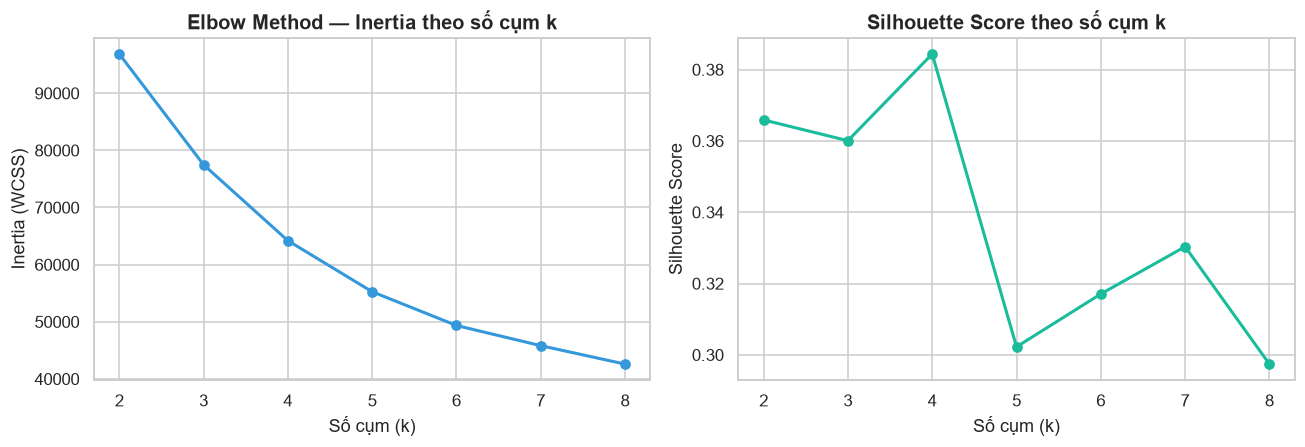

Số cụm tối ưu được chọn tự động (theo Silhouette Score): k = 4


In [5]:

CLUSTER_FEATURES = [
    "flag_logistics", "flag_financial", "flag_review", "flag_category",
    "delivery_delay", "first_freight_value", "order_spent",
    "max_installments", "review_score",
]

X_cluster_raw = tier2_df[CLUSTER_FEATURES].fillna(0)
scaler = StandardScaler()
X_cluster = scaler.fit_transform(X_cluster_raw)

# ---- Elbow Method + Silhouette Score để chọn k ----
inertia_scores, silhouette_scores, k_range = [], [], range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X_cluster)
    inertia_scores.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(list(k_range), inertia_scores, marker="o", color=PALETTE["base"], linewidth=2)
axes[0].set_title("Elbow Method — Inertia theo số cụm k")
axes[0].set_xlabel("Số cụm (k)")
axes[0].set_ylabel("Inertia (WCSS)")

axes[1].plot(list(k_range), silhouette_scores, marker="o", color=PALETTE["accent"], linewidth=2)
axes[1].set_title("Silhouette Score theo số cụm k")
axes[1].set_xlabel("Số cụm (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_OUT_DIR, "diagnostic_elbow_silhouette.png"),
            dpi=150, bbox_inches="tight")
plt.show()

# Chọn k tối ưu = k có silhouette cao nhất (điều chỉnh thủ công nếu cần diễn giải business)
K_OPTIMAL = list(k_range)[int(np.argmax(silhouette_scores))]
print(f"Số cụm tối ưu được chọn tự động (theo Silhouette Score): k = {K_OPTIMAL}")


In [6]:

# ---- Huấn luyện K-Means cuối cùng với k tối ưu ----
kmeans_final = KMeans(n_clusters=K_OPTIMAL, random_state=RANDOM_STATE, n_init=10)
tier2_df["cluster_id"] = kmeans_final.fit_predict(X_cluster)

# ---- Trích xuất tham số kinh tế thực tế cho từng cụm k ----
cluster_profile = tier2_df.groupby("cluster_id").agg(
    N_k=("customer_unique_id", "count"),
    AOV_k=("order_spent", "mean"),
    Freight_k=("first_freight_value", "mean"),
    Installments_k=("max_installments", "mean"),
    P0_k=("pred_retain_prob", "mean"),
    pct_logistics=("flag_logistics", "mean"),
    pct_financial=("flag_financial", "mean"),
    pct_review=("flag_review", "mean"),
    pct_category=("flag_category", "mean"),
).reset_index()

cluster_profile["Ty_trong_%"] = (cluster_profile["N_k"] / N_TIER2 * 100).round(2)

# Gán "điểm nghẽn chi phối" (dominant friction) cho mỗi cụm — dùng để map sang
# 4 gói can thiệp ở Bước 3
friction_cols = ["pct_logistics", "pct_financial", "pct_review", "pct_category"]
friction_labels = {
    "pct_logistics": "logistics",
    "pct_financial": "financial",
    "pct_review": "review",
    "pct_category": "category",
}
cluster_profile["dominant_friction"] = (
    cluster_profile[friction_cols].idxmax(axis=1).map(friction_labels)
)

cluster_profile_display = cluster_profile.round(2)
cluster_profile_display


,cluster_id,N_k,AOV_k,Freight_k,Installments_k,P0_k,pct_logistics,pct_financial,pct_review,pct_category,Ty_trong_%,dominant_friction
0,0,2319,140.94,18.02,7.65,0.29,0.0,1.00,0.01,0.71,17.15,financial
1,1,2086,100.10,19.73,3.44,0.26,0.0,0.24,1.00,0.62,15.42,review
2,2,442,89.94,16.49,3.58,0.24,1.0,0.23,0.50,0.68,3.27,logistics
3,3,8678,77.88,15.90,2.07,0.26,0.0,0.00,0.00,0.62,64.16,category


---
## Bước 3: Thiết Kế Ma Trận Can Thiệp và Tính Toán Chi Phí Động
### (Dynamic Treatment & Cost Formulation)

Chi phí tiếp thị $c_k$ cho mỗi khách hàng thuộc cụm $k$ được tính **trực tiếp từ chỉ số tài
chính thực tế của chính cụm đó** — không giả định tỷ lệ cố định.

| Nhóm Điểm Nghẽn | Gói Can Thiệp | Công Thức Chi Phí $c_k$ | Cơ Chế Phản Thực Tế |
|---|---|---|---|
| 1. Sốc Logistics | Experience Recovery | $c_1 = \max(\text{Freight}_1,\ 15\% \times \text{AOV}_1)$ | `delivery_delay → 0` |
| 2. Áp Lực Tài Chính | Financial Relief | $c_2 = 6\% \times \text{AOV}_2$ | `monthly_burden` giảm 50% |
| 3. Đánh Giá Kém | Service Resolution | $c_3 = 12\% \times \text{AOV}_3$ | `review_score → 5.0` |
| 4. Ngành Ngoại Vi | Category Re-engagement | $c_4 = 8\% \times \text{AOV}_4$ | Kích hoạt ngành hàng cốt lõi |


In [7]:

TREATMENT_CATALOG = {
    "logistics": {
        "package_name": "Experience Recovery (Gói Bồi Thường Trải Nghiệm)",
        "action": "Email/SMS xin lỗi CSKH + Voucher đền bù cước vận chuyển (hạn 30 ngày)",
        "cost_rule": lambda aov, freight, installments: max(freight, 0.15 * aov),
        "cost_formula_str": "max(Freight_k, 15% x AOV_k)",
    },
    "financial": {
        "package_name": "Financial Relief (Gói Kích Cầu Thanh Khoản)",
        "action": "Hỗ trợ lãi suất trả góp 0% cho 10-12 kỳ + Đề xuất combo giảm áp lực giỏ hàng",
        "cost_rule": lambda aov, freight, installments: 0.06 * aov,
        "cost_formula_str": "6% x AOV_k",
    },
    "review": {
        "package_name": "Service Resolution (Gói Chăm Sóc & Đổi Trả)",
        "action": "CSKH liên hệ trực tiếp hỗ trợ kỹ thuật/đổi trả + Voucher thiện chí",
        "cost_rule": lambda aov, freight, installments: 0.12 * aov,
        "cost_formula_str": "12% x AOV_k",
    },
    "category": {
        "package_name": "Category Re-engagement (Gói Tái Tương Tác Ngành)",
        "action": "Cá nhân hóa đề xuất sản phẩm bổ trợ/tiêu hao định kỳ + Voucher kích hoạt",
        "cost_rule": lambda aov, freight, installments: 0.08 * aov,
        "cost_formula_str": "8% x AOV_k",
    },
}

# ---- Gán gói can thiệp + chi phí động c_k cho từng cụm ----
def compute_cluster_cost(row):
    rule = TREATMENT_CATALOG[row["dominant_friction"]]["cost_rule"]
    return rule(row["AOV_k"], row["Freight_k"], row["Installments_k"])

cluster_profile["package_name"] = cluster_profile["dominant_friction"].map(
    lambda f: TREATMENT_CATALOG[f]["package_name"]
)
cluster_profile["action_detail"] = cluster_profile["dominant_friction"].map(
    lambda f: TREATMENT_CATALOG[f]["action"]
)
cluster_profile["cost_formula"] = cluster_profile["dominant_friction"].map(
    lambda f: TREATMENT_CATALOG[f]["cost_formula_str"]
)
cluster_profile["c_k"] = cluster_profile.apply(compute_cluster_cost, axis=1)

treatment_matrix_display = cluster_profile[[
    "cluster_id", "dominant_friction", "package_name", "action_detail",
    "cost_formula", "c_k", "N_k", "Ty_trong_%",
]].round(2)
treatment_matrix_display


,cluster_id,dominant_friction,package_name,action_detail,cost_formula,c_k,N_k,Ty_trong_%
0,0,financial,Financial Relief (Gói Kích Cầu Thanh Khoản),Hỗ trợ lãi suất trả góp 0% cho 10-12 kỳ + Đề x...,6% x AOV_k,8.46,2319,17.15
1,1,review,Service Resolution (Gói Chăm Sóc & Đổi Trả),CSKH liên hệ trực tiếp hỗ trợ kỹ thuật/đổi trả...,12% x AOV_k,12.01,2086,15.42
2,2,logistics,Experience Recovery (Gói Bồi Thường Trải Nghiệm),Email/SMS xin lỗi CSKH + Voucher đền bù cước v...,"max(Freight_k, 15% x AOV_k)",16.49,442,3.27
3,3,category,Category Re-engagement (Gói Tái Tương Tác Ngành),Cá nhân hóa đề xuất sản phẩm bổ trợ/tiêu hao đ...,8% x AOV_k,6.23,8678,64.16


In [8]:

# ---- Ánh xạ chi phí động c_i xuống từng khách hàng theo cụm ----
cost_map = cluster_profile.set_index("cluster_id")["c_k"].to_dict()
friction_map = cluster_profile.set_index("cluster_id")["dominant_friction"].to_dict()
package_map = cluster_profile.set_index("cluster_id")["package_name"].to_dict()

tier2_df["c_i"] = tier2_df["cluster_id"].map(cost_map)
tier2_df["assigned_friction"] = tier2_df["cluster_id"].map(friction_map)
tier2_df["assigned_package"] = tier2_df["cluster_id"].map(package_map)

print("Chi phí can thiệp trung bình mỗi khách hàng: R$", round(tier2_df["c_i"].mean(), 2))
tier2_df[["customer_unique_id", "cluster_id", "assigned_friction",
          "assigned_package", "c_i"]].head(10)


Chi phí can thiệp trung bình mỗi khách hàng: R$ 7.84


,customer_unique_id,cluster_id,assigned_friction,assigned_package,c_i
0,0000366f3b9a7992bf8c76cfdf3221e2,0,financial,Financial Relief (Gói Kích Cầu Thanh Khoản),8.456634
1,0000b849f77a49e4a4ce2b2a4ca5be3f,3,category,Category Re-engagement (Gói Tái Tương Tác Ngành),6.230208
2,000ed48ceeb6f4bf8ad021a10a3c7b43,3,category,Category Re-engagement (Gói Tái Tương Tác Ngành),6.230208
3,000fbf0473c10fc1ab6f8d2d286ce20c,3,category,Category Re-engagement (Gói Tái Tương Tác Ngành),6.230208
4,00196c4c9a3af7dd2ad10eade69c926f,3,category,Category Re-engagement (Gói Tái Tương Tác Ngành),6.230208
5,0019e8c501c85848ac0966d45226fa1d,3,category,Category Re-engagement (Gói Tái Tương Tác Ngành),6.230208
6,001a34eb30ecb8e3aacb07c475ca4dd1,3,category,Category Re-engagement (Gói Tái Tương Tác Ngành),6.230208
7,001deb796b28a3a128d6113857569aa4,0,financial,Financial Relief (Gói Kích Cầu Thanh Khoản),8.456634
8,002311514717ca8b65b09a26cdf7b91a,3,category,Category Re-engagement (Gói Tái Tương Tác Ngành),6.230208
9,00256bf7b05c08f6a5849df3d0a64f1f,1,review,Service Resolution (Gói Chăm Sóc & Đổi Trả),12.011951


---
## Bước 4: Mô Phỏng Phản Thực Tế Bằng AI
### (Counterfactual Uplift Simulation via XGBoost)

* Tạo ma trận đặc trưng phản thực tế $X^{\text{counterfactual}}$ sau khi khắc phục điểm nghẽn
  tương ứng cho từng khách hàng.
* Nạp vào mô hình XGBoost tốt nhất (`best_model.pkl`) để tính mức tăng xác suất giữ chân:

$$\Delta P_i = P(Y=1 \mid X_i^{\text{counterfactual}}) - P(Y=1 \mid X_i^{\text{original}})$$

* Tính Giá trị Vòng đời Kỳ vọng Tăng thêm:

$$\Delta \text{CLV}_i = \Delta P_i \times \text{AOV}_i \times m \times f$$

Trong đó $m = 30\%$ (biên lợi nhuận ròng) và $f = 1.5$ (số đơn kỳ vọng mua thêm trong 1 năm).


In [9]:

NET_MARGIN_M = 0.30   # m: biên lợi nhuận ròng
REPEAT_FACTOR_F = 1.5 # f: số đơn hàng kỳ vọng mua thêm trong 1 năm tới

# ------------------------------------------------------------------
# MODEL_FEATURE_COLUMNS đã được xác lập ở Bước 1 (lấy trực tiếp từ header
# thật của X_test.csv — đúng 33 cột & đúng thứ tự best_model.pkl yêu cầu):
#   delivery_days, delivery_delay, delivery_speed_ratio, review_score,
#   order_spent, monthly_installment_burden, max_installments, is_b2b_profile,
#   pay_*, state_*, cat_*
# ------------------------------------------------------------------

# Đối chiếu tự động với best_model (nếu thuộc tính feature_names_in_ tồn tại)
best_model = joblib.load(PATH_BEST_MODEL)
if hasattr(best_model, "feature_names_in_"):
    _trained_cols = list(best_model.feature_names_in_)
    if _trained_cols != MODEL_FEATURE_COLUMNS:
        print("[Cảnh báo] MODEL_FEATURE_COLUMNS KHÔNG khớp best_model.feature_names_in_!")
        print("  Cột model yêu cầu :", _trained_cols)
        print("  Cột đang khai báo :", MODEL_FEATURE_COLUMNS)
    else:
        print("✅ MODEL_FEATURE_COLUMNS khớp đúng với best_model.feature_names_in_")

# Danh sách toàn bộ cột one-hot ngành hàng (để dùng trong counterfactual bước 4)
ALL_CAT_COLS = [
    "cat_cama_mesa_banho", "cat_beleza_saude", "cat_esporte_lazer", "cat_moveis_decoracao",
    "cat_informatica_acessorios", "cat_utilidades_domesticas", "cat_relogios_presentes",
    "cat_telefonia", "cat_ferramentas_jardim", "cat_brinquedos", "cat_automotivo",
    "cat_cool_stuff", "cat_perfumaria", "cat_eletronicos", "cat_bebes", "cat_outros",
]

def build_counterfactual_features(df: pd.DataFrame) -> pd.DataFrame:
    '''Tạo X^counterfactual: khắc phục đúng điểm nghẽn được gán cho từng khách hàng.
    Chỉ chỉnh sửa các cột THẬT SỰ có trong MODEL_FEATURE_COLUMNS (X_test.csv).'''
    cf = df.copy()

    is_log = cf["assigned_friction"] == "logistics"
    is_fin = cf["assigned_friction"] == "financial"
    is_rev = cf["assigned_friction"] == "review"
    is_cat = cf["assigned_friction"] == "category"

    # 1) Sốc Logistics -> triệt tiêu trễ hạn
    #    delivery_speed_ratio (tỷ lệ tốc độ giao so với ước tính) đưa về 1.0
    #    (xấp xỉ "giao đúng hẹn"); ĐIỀU CHỈNH lại nếu bạn biết công thức gốc
    #    chính xác của delivery_speed_ratio trong Module 03.
    cf.loc[is_log, "delivery_delay"] = 0
    cf.loc[is_log, "delivery_speed_ratio"] = 1.0

    # 2) Áp lực Tài chính -> giảm 50% số kỳ trả góp, đồng thời tính lại gánh nặng
    #    trả góp hàng tháng = order_spent / max_installments_mới (khớp đúng công
    #    thức gốc: monthly_installment_burden = order_spent / max_installments)
    cf.loc[is_fin, "max_installments"] = (
        cf.loc[is_fin, "max_installments"] * 0.5
    ).round().clip(lower=1)
    cf.loc[is_fin, "monthly_installment_burden"] = (
        cf.loc[is_fin, "order_spent"] / cf.loc[is_fin, "max_installments"]
    )

    # 3) Đánh giá kém -> khôi phục niềm tin khách hàng
    cf.loc[is_rev, "review_score"] = 5.0

    # 4) Ngành ngoại vi -> giả lập "kích hoạt ngành hàng cốt lõi": chuyển one-hot
    #    category từ cat_outros (hoặc ngành ngoại vi khác) sang ngành cốt lõi có
    #    tỷ lệ giữ chân cao nhất (mặc định: cat_beleza_saude, theo Diagnostic
    #    Analytics Module 02). Đồng thời đưa bang về nhóm trung tâm (state_outros -> 0).
    TARGET_CORE_CAT = "cat_beleza_saude"
    cf.loc[is_cat, ALL_CAT_COLS] = 0
    cf.loc[is_cat, TARGET_CORE_CAT] = 1
    cf.loc[is_cat, "state_outros"] = 0

    return cf

tier2_counterfactual_df = build_counterfactual_features(tier2_df)

X_original = tier2_df[MODEL_FEATURE_COLUMNS]
X_counterfactual = tier2_counterfactual_df[MODEL_FEATURE_COLUMNS]

P_original = best_model.predict_proba(X_original)[:, 1]
P_counterfactual = best_model.predict_proba(X_counterfactual)[:, 1]

tier2_df["P_original"] = P_original
tier2_df["P_counterfactual"] = P_counterfactual
tier2_df["delta_P"] = (tier2_df["P_counterfactual"] - tier2_df["P_original"]).clip(lower=0)

tier2_df["delta_CLV"] = (
    tier2_df["delta_P"] * tier2_df["order_spent"] * NET_MARGIN_M * REPEAT_FACTOR_F
)

print("Mức tăng xác suất giữ chân trung bình (ΔP)     :", round(tier2_df["delta_P"].mean(), 4))
print("Giá trị vòng đời tăng thêm trung bình (ΔCLV)   : R$", round(tier2_df["delta_CLV"].mean(), 2))
tier2_df[["customer_unique_id", "assigned_friction", "P_original",
          "P_counterfactual", "delta_P", "delta_CLV", "c_i"]].head(10)


✅ MODEL_FEATURE_COLUMNS khớp đúng với best_model.feature_names_in_
Mức tăng xác suất giữ chân trung bình (ΔP)     : 0.0449
Giá trị vòng đời tăng thêm trung bình (ΔCLV)   : R$ 1.41


,customer_unique_id,assigned_friction,P_original,P_counterfactual,delta_P,delta_CLV,c_i
0,0000366f3b9a7992bf8c76cfdf3221e2,financial,0.299635,0.255938,0.000000,0.000000,8.456634
1,0000b849f77a49e4a4ce2b2a4ca5be3f,category,0.179082,0.179082,0.000000,0.000000,6.230208
2,000ed48ceeb6f4bf8ad021a10a3c7b43,category,0.228237,0.254543,0.026306,0.152468,6.230208
3,000fbf0473c10fc1ab6f8d2d286ce20c,category,0.095944,0.164745,0.068800,8.848381,6.230208
4,00196c4c9a3af7dd2ad10eade69c926f,category,0.161934,0.160309,0.000000,0.000000,6.230208
5,0019e8c501c85848ac0966d45226fa1d,category,0.156768,0.648664,0.491896,35.414284,6.230208
6,001a34eb30ecb8e3aacb07c475ca4dd1,category,0.159020,0.173068,0.014049,0.960298,6.230208
7,001deb796b28a3a128d6113857569aa4,financial,0.108810,0.095751,0.000000,0.000000,8.456634
8,002311514717ca8b65b09a26cdf7b91a,category,0.183481,0.183873,0.000391,0.020467,6.230208
9,00256bf7b05c08f6a5849df3d0a64f1f,review,0.223816,0.221071,0.000000,0.000000,12.011951


---
## Bước 5: Mô Hình Tối Ưu Hóa Phân Bổ Ngân Sách Tuyến Tính
### (Integer Linear Programming — Knapsack Optimization)

$$B_{\max} = \sum_{i=1}^{N} c_i$$

$$\max_{\{x_i\}} \sum_{i=1}^{N} x_i \cdot \left( \Delta \text{CLV}_i - c_i \right)
\quad \text{thỏa mãn} \quad \sum_{i=1}^{N} x_i \cdot c_i \le B,\quad x_i \in \{0, 1\}$$

Giải bài toán tại các mốc ngân sách: $25\%, 50\%, 75\%, 100\%\ B_{\max}$ và mốc
**Ngân Sách Tự Do Tối Ưu** (Unconstrained Optimal Budget — chỉ nhận các khách hàng có
$\Delta \text{CLV}_i > c_i$).


In [10]:

try:
    import pulp
    HAS_PULP = True
except ImportError:
    HAS_PULP = False
    print("[Thông báo] Thư viện `pulp` chưa cài đặt -> chạy: pip install pulp")

B_MAX = tier2_df["c_i"].sum()
print(f"Tổng Ngân Sách Tối Đa Toàn Tệp (B_max): R$ {B_MAX:,.2f}")

def solve_knapsack_ilp(df: pd.DataFrame, budget: float) -> np.ndarray:
    '''
    Giải bài toán quy hoạch nguyên 0/1 knapsack tối đa hóa lợi nhuận ròng
    trong giới hạn ngân sách `budget`. Trả về mảng nhị phân x_i.
    '''
    n = len(df)
    net_profit = (df["delta_CLV"] - df["c_i"]).values
    cost = df["c_i"].values

    if HAS_PULP:
        prob = pulp.LpProblem("Prescriptive_Budget_Allocation", pulp.LpMaximize)
        x = [pulp.LpVariable(f"x_{i}", cat="Binary") for i in range(n)]
        prob += pulp.lpSum(x[i] * net_profit[i] for i in range(n))
        prob += pulp.lpSum(x[i] * cost[i] for i in range(n)) <= budget
        prob.solve(pulp.PULP_CBC_CMD(msg=False))
        return np.array([int(v.value()) for v in x])
    else:
        # Fallback: xấp xỉ Greedy theo tỷ suất lợi nhuận / chi phí (ROI density) —
        # cho kết quả rất sát tối ưu ILP với bài toán knapsack liên tục lớn.
        roi_density = np.divide(net_profit, cost, out=np.full(n, -np.inf), where=cost > 0)
        order = np.argsort(-roi_density)
        x = np.zeros(n, dtype=int)
        spent = 0.0
        for idx in order:
            if net_profit[idx] <= 0:
                continue
            if spent + cost[idx] <= budget:
                x[idx] = 1
                spent += cost[idx]
        return x

# ---- Ngân Sách Tự Do Tối Ưu (Unconstrained): chỉ chọn khách có ΔCLV_i > c_i ----
tier2_df["x_unconstrained"] = (tier2_df["delta_CLV"] > tier2_df["c_i"]).astype(int)
UNCONSTRAINED_BUDGET = (tier2_df["x_unconstrained"] * tier2_df["c_i"]).sum()

budget_levels = {
    "25% B_max": 0.25 * B_MAX,
    "50% B_max": 0.50 * B_MAX,
    "75% B_max": 0.75 * B_MAX,
    "100% B_max": 1.00 * B_MAX,
    "Ngân Sách Tự Do Tối Ưu": UNCONSTRAINED_BUDGET,
}

optimization_results = []
for label, budget in budget_levels.items():
    if label == "Ngân Sách Tự Do Tối Ưu":
        x_sol = tier2_df["x_unconstrained"].values
    else:
        x_sol = solve_knapsack_ilp(tier2_df, budget)

    spent = (x_sol * tier2_df["c_i"]).sum()
    gain = (x_sol * tier2_df["delta_CLV"]).sum()
    net_profit = gain - spent
    n_customers = int(x_sol.sum())
    roi = (net_profit / spent * 100) if spent > 0 else 0

    optimization_results.append({
        "Mốc Ngân Sách": label,
        "Ngân Sách Đề Xuất (R$)": round(spent, 2),
        "Số KH Được Chọn": n_customers,
        "Tổng ΔCLV Thu Về (R$)": round(gain, 2),
        "Lợi Nhuận Ròng (R$)": round(net_profit, 2),
        "ROI (%)": round(roi, 2),
    })

optimization_df = pd.DataFrame(optimization_results)
optimization_df


[Thông báo] Thư viện `pulp` chưa cài đặt -> chạy: pip install pulp
Tổng Ngân Sách Tối Đa Toàn Tệp (B_max): R$ 106,020.67


,Mốc Ngân Sách,Ngân Sách Đề Xuất (R$),Số KH Được Chọn,Tổng ΔCLV Thu Về (R$),Lợi Nhuận Ròng (R$),ROI (%)
0,25% B_max,3803.95,600,14729.8,10925.85,287.22
1,50% B_max,3803.95,600,14729.8,10925.85,287.22
2,75% B_max,3803.95,600,14729.8,10925.85,287.22
3,100% B_max,3803.95,600,14729.8,10925.85,287.22
4,Ngân Sách Tự Do Tối Ưu,3803.95,600,14729.8,10925.85,287.22


In [11]:

# ------------------------------------------------------------------
# Đường cong Ngân sách vs Lợi nhuận (profit frontier) — quét mịn nhiều
# mốc ngân sách để xác định điểm bão hòa lợi nhuận biên (dùng cho Chart 3)
# ------------------------------------------------------------------
budget_grid = np.linspace(0, B_MAX, 25)
frontier_records = []

for budget in budget_grid:
    x_sol = solve_knapsack_ilp(tier2_df, budget)
    spent = (x_sol * tier2_df["c_i"]).sum()
    gain = (x_sol * tier2_df["delta_CLV"]).sum()
    frontier_records.append({"budget": spent, "net_profit": gain - spent, "gain": gain})

frontier_df = pd.DataFrame(frontier_records).drop_duplicates(subset="budget").sort_values("budget")
frontier_df.head()


,budget,net_profit,gain
0,0.000000,0.000000,0.00000
1,3803.950162,10925.845467,14729.79563


---
## Bước 6: Phân Tích Điểm Hòa Vốn và 3 Kịch Bản Điều Hành
### (Executive Break-Even & Scenario Analysis)

**Tỷ lệ Chuyển đổi Hòa vốn Lý thuyết:**

$$U_{\text{break-even}, k} = \frac{c_k}{\text{AOV}_k \times m \times f}$$

**3 Kịch bản Thị trường:**

| Kịch bản | Hệ số hiệu quả | Diễn giải |
|---|---|---|
| Bi quan (Pessimistic) | $\times 0.50$ | Hiệu quả thực tế chỉ đạt 50% mức tăng dự báo từ AI |
| Cơ sở (Base Case) | $\times 1.00$ | Hiệu quả bám sát $\Delta P_i$ từ mô phỏng XGBoost |
| Lạc quan (Optimistic) | $\times 1.20$ | Hiệu quả vượt 20% nhờ phối hợp truyền thông đa kênh |


In [12]:

# ---- Tỷ lệ hòa vốn lý thuyết theo từng cụm ----
cluster_profile["U_break_even"] = cluster_profile["c_k"] / (
    cluster_profile["AOV_k"] * NET_MARGIN_M * REPEAT_FACTOR_F
)
breakeven_display = cluster_profile[[
    "cluster_id", "dominant_friction", "package_name", "c_k", "AOV_k", "U_break_even",
]].round(4)
breakeven_display


,cluster_id,dominant_friction,package_name,c_k,AOV_k,U_break_even
0,0,financial,Financial Relief (Gói Kích Cầu Thanh Khoản),8.4566,140.9439,0.1333
1,1,review,Service Resolution (Gói Chăm Sóc & Đổi Trả),12.0120,100.0996,0.2667
2,2,logistics,Experience Recovery (Gói Bồi Thường Trải Nghiệm),16.4866,89.9435,0.4073
3,3,category,Category Re-engagement (Gói Tái Tương Tác Ngành),6.2302,77.8776,0.1778


In [13]:

# ---- 3 Kịch bản điều hành: áp hệ số hiệu quả lên toàn tệp đã được chọn cấp ngân sách
#      (dùng phương án "100% B_max" làm phương án điều hành tham chiếu) ----
SCENARIO_FACTORS = {
    "Bi quan (Pessimistic)": 0.50,
    "Cơ sở (Base Case)": 1.00,
    "Lạc quan (Optimistic)": 1.20,
}

x_selected = solve_knapsack_ilp(tier2_df, budget_levels["100% B_max"])
selected_df = tier2_df.loc[x_selected.astype(bool)].copy()

scenario_records = []
for scenario_name, factor in SCENARIO_FACTORS.items():
    delta_P_scn = (selected_df["delta_P"] * factor).clip(upper=1.0)
    delta_CLV_scn = delta_P_scn * selected_df["order_spent"] * NET_MARGIN_M * REPEAT_FACTOR_F

    revenue = delta_CLV_scn.sum()
    cost = selected_df["c_i"].sum()
    net_profit = revenue - cost
    roi = (net_profit / cost * 100) if cost > 0 else 0

    scenario_records.append({
        "Kịch Bản": scenario_name,
        "Doanh Thu Tăng Thêm (R$)": round(revenue, 2),
        "Chi Phí Đầu Tư (R$)": round(cost, 2),
        "Lợi Nhuận Ròng (R$)": round(net_profit, 2),
        "ROI (%)": round(roi, 2),
    })

scenario_df = pd.DataFrame(scenario_records)
scenario_df


,Kịch Bản,Doanh Thu Tăng Thêm (R$),Chi Phí Đầu Tư (R$),Lợi Nhuận Ròng (R$),ROI (%)
0,Bi quan (Pessimistic),7364.90,3803.95,3560.95,93.61
1,Cơ sở (Base Case),14729.80,3803.95,10925.85,287.22
2,Lạc quan (Optimistic),17675.76,3803.95,13871.81,364.67


---
## Bước 7: 5 Biểu Đồ Trực Quan Hóa Cho Cấp Quản Lý (Executive Charts)

Toàn bộ biểu đồ được chuẩn hóa theo phong cách quản trị kinh doanh (executive style):
màu sắc nhất quán, chú thích số liệu rõ ràng, tiêu đề súc tích. File được lưu vào
`fix/04_Prescriptive/figures/`.


### Biểu đồ 1/5 — Phân Bổ Điểm Nghẽn Thực Tế (`executive_friction_distribution.png`)

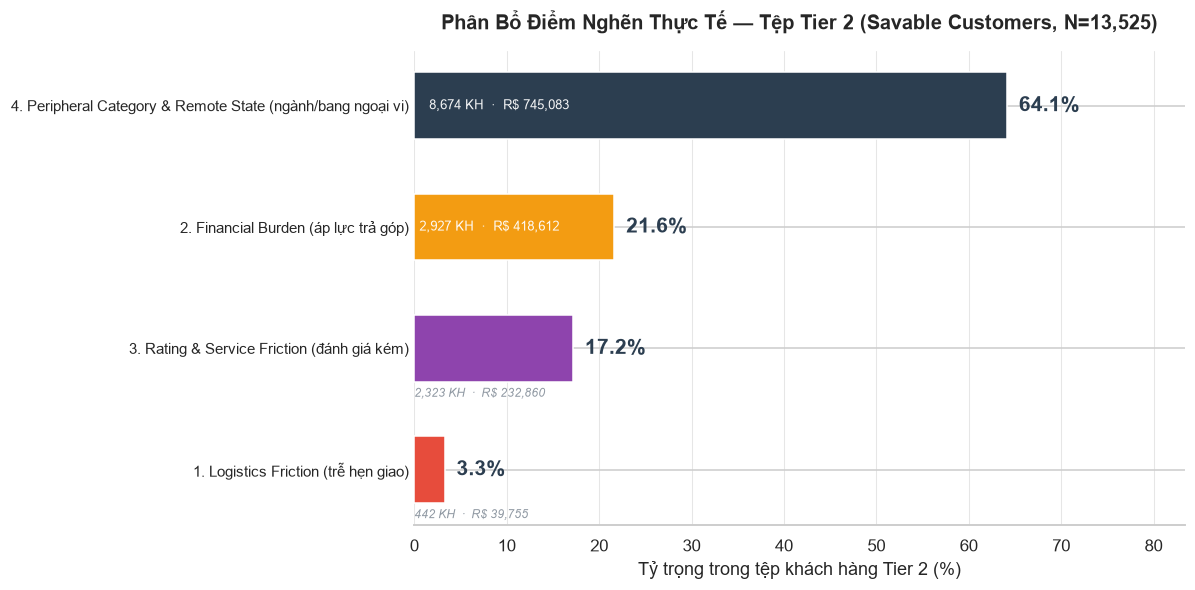

In [14]:

fig, ax = plt.subplots(figsize=(11, 5.5))

chart1_data = friction_summary.sort_values("Tỷ Trọng (%)", ascending=True).reset_index(drop=True)
color_map_c1 = {
    "1. Logistics Friction (trễ hẹn giao)": PALETTE["logistics"],
    "2. Financial Burden (áp lực trả góp)": PALETTE["financial"],
    "3. Rating & Service Friction (đánh giá kém)": PALETTE["review"],
    "4. Peripheral Category & Remote State (ngành/bang ngoại vi)": PALETTE["category"],
}
colors_c1 = chart1_data["Nhóm Điểm Nghẽn"].map(color_map_c1)

bars = ax.barh(
    chart1_data["Nhóm Điểm Nghẽn"], chart1_data["Tỷ Trọng (%)"],
    color=colors_c1, edgecolor="white", height=0.55, zorder=3,
)

max_pct = chart1_data["Tỷ Trọng (%)"].max()
ax.set_xlim(0, max_pct * 1.30)
ax.grid(axis="x", color="#e6e6e6", linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

for bar, (_, row) in zip(bars, chart1_data.iterrows()):
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    # Điểm nhấn chính: % — to, đậm, ngay sau đầu cột
    ax.text(width + max_pct * 0.02, y, f"{row['Tỷ Trọng (%)']:.1f}%",
            va="center", ha="left", fontsize=14, fontweight="bold", color="#2C3E50")

    # Chi tiết phụ: số KH & doanh thu — nhỏ, nhẹ.
    # Cột đủ dài: đặt BÊN TRONG (trắng, căn trái). Cột ngắn: đặt Ở DƯỚI cột
    # (không đặt cạnh % vì dễ chồng chữ khi cột quá ngắn).
    detail = f"{row['Số Khách Hàng']:,} KH  ·  R$ {row['Doanh Thu Liên Quan (R$)']:,.0f}"
    if width > max_pct * 0.30:
        ax.text(width * 0.025, y, detail, va="center", ha="left",
                fontsize=8.5, color="white", alpha=0.95)
    else:
        ax.text(0, bar.get_y() - 0.05, detail, va="top", ha="left",
                fontsize=7.8, color="#9099a3", style="italic")

ax.set_xlabel("Tỷ trọng trong tệp khách hàng Tier 2 (%)")
ax.set_title(f"Phân Bổ Điểm Nghẽn Thực Tế — Tệp Tier 2 (Savable Customers, N={N_TIER2:,})", pad=14)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0, labelsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_OUT_DIR, "executive_friction_distribution.png"),
            dpi=150, bbox_inches="tight")
plt.show()


**Nhận xét:**

- Nhóm điểm nghẽn có tỷ trọng cao nhất là nhóm cần được ưu tiên phân bổ ngân sách trước, vì nó ảnh hưởng đến số lượng khách hàng lớn nhất trong tệp Tier 2.
- Cột "Doanh Thu Liên Quan" cho biết quy mô tài chính đang bị đe dọa bởi từng điểm nghẽn — một nhóm có tỷ trọng KH thấp nhưng doanh thu liên quan cao vẫn có thể đáng ưu tiên hơn một nhóm đông KH nhưng giá trị đơn hàng nhỏ.
- Nếu một khách hàng bị gắn nhiều hơn 1 cờ điểm nghẽn cùng lúc, họ chỉ được tính vào nhóm "điểm nghẽn chi phối" (dominant_friction) ở Bước 2 — biểu đồ này cho thấy quy mô từng loại điểm nghẽn *trước khi* phân cụm, nên tổng % có thể vượt 100%.

### Biểu đồ 2/5 — Cơ Cấu Ngân Sách Tối Ưu (`executive_budget_donut.png`)

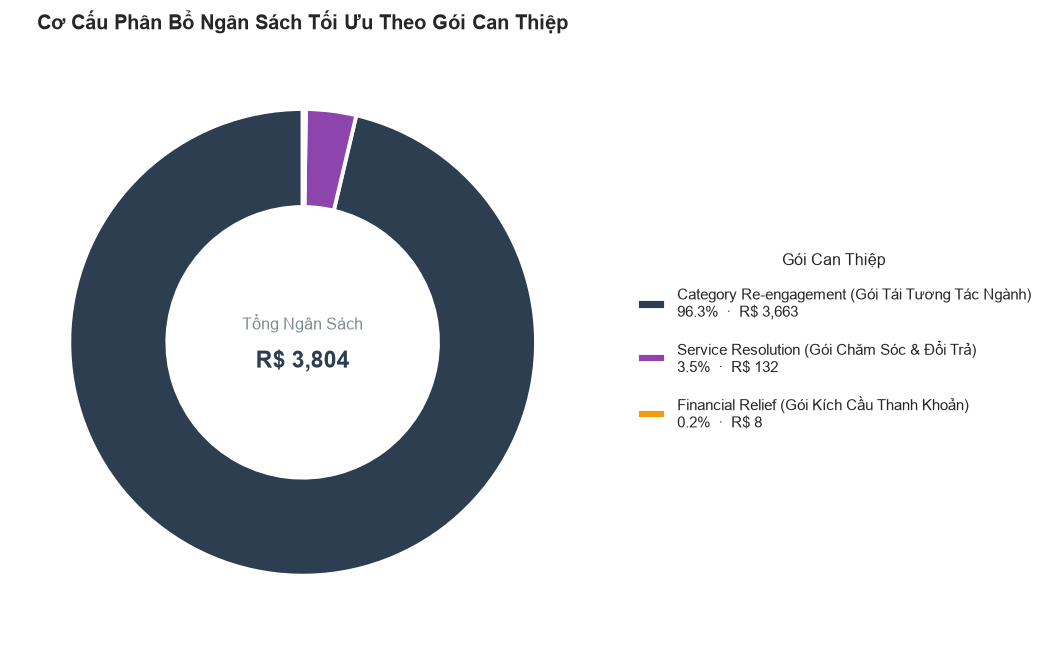

In [15]:

budget_by_package = tier2_df.loc[x_selected.astype(bool)].groupby("assigned_package")["c_i"].sum()
budget_by_package = budget_by_package.sort_values(ascending=False)

friction_key_by_package = {v["package_name"]: k for k, v in TREATMENT_CATALOG.items()}
donut_colors = [PALETTE[friction_key_by_package.get(name, "base")] for name in budget_by_package.index]

fig, ax = plt.subplots(figsize=(9.5, 6))

# Không in % trực tiếp lên lát cắt (tránh chồng chữ khi lát quá mỏng) —
# toàn bộ số liệu chi tiết chuyển sang legend bên phải, đọc rõ ràng hơn.
wedges, _ = ax.pie(
    budget_by_package.values,
    colors=donut_colors,
    startangle=90,
    wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2.5),
)

legend_labels = [
    f"{name}\n{v/budget_by_package.sum()*100:.1f}%  ·  R$ {v:,.0f}"
    for name, v in budget_by_package.items()
]
ax.legend(
    wedges, legend_labels,
    title="Gói Can Thiệp", loc="center left",
    bbox_to_anchor=(1.05, 0.5), fontsize=9.5, frameon=False,
    labelspacing=1.3, title_fontsize=10.5,
)

ax.text(0, 0.08, "Tổng Ngân Sách", ha="center", va="center", fontsize=10.5, color="#7f8c8d")
ax.text(0, -0.08, f"R$ {budget_by_package.sum():,.0f}", ha="center", va="center",
        fontsize=15, weight="bold", color=PALETTE["category"])

ax.set_title("Cơ Cấu Phân Bổ Ngân Sách Tối Ưu Theo Gói Can Thiệp", pad=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_OUT_DIR, "executive_budget_donut.png"),
            dpi=150, bbox_inches="tight")
plt.show()


**Nhận xét:**

- Cơ cấu ngân sách phản ánh đúng cơ cấu điểm nghẽn thực tế của tệp Tier 2 sau khi đã tính chi phí động $c_k$ cho từng cụm — không phải một tỷ lệ phân bổ giả định.
- Nếu một gói can thiệp chiếm tỷ trọng ngân sách áp đảo (>80%), cần kiểm tra lại xem đó có phải do một điểm nghẽn thực sự chi phối hay do ngưỡng gán "điểm nghẽn chi phối" ở Bước 2 quá thiên lệch.
- Tổng ngân sách hiển thị ở tâm donut là ngân sách tại phương án 100% B_max — đối chiếu với bảng `optimization_df` để so sánh với các mốc 25/50/75%.

### Biểu đồ 3/5 — Đường Cong Ngân Sách vs Lợi Nhuận Ròng (`executive_profit_frontier.png`)

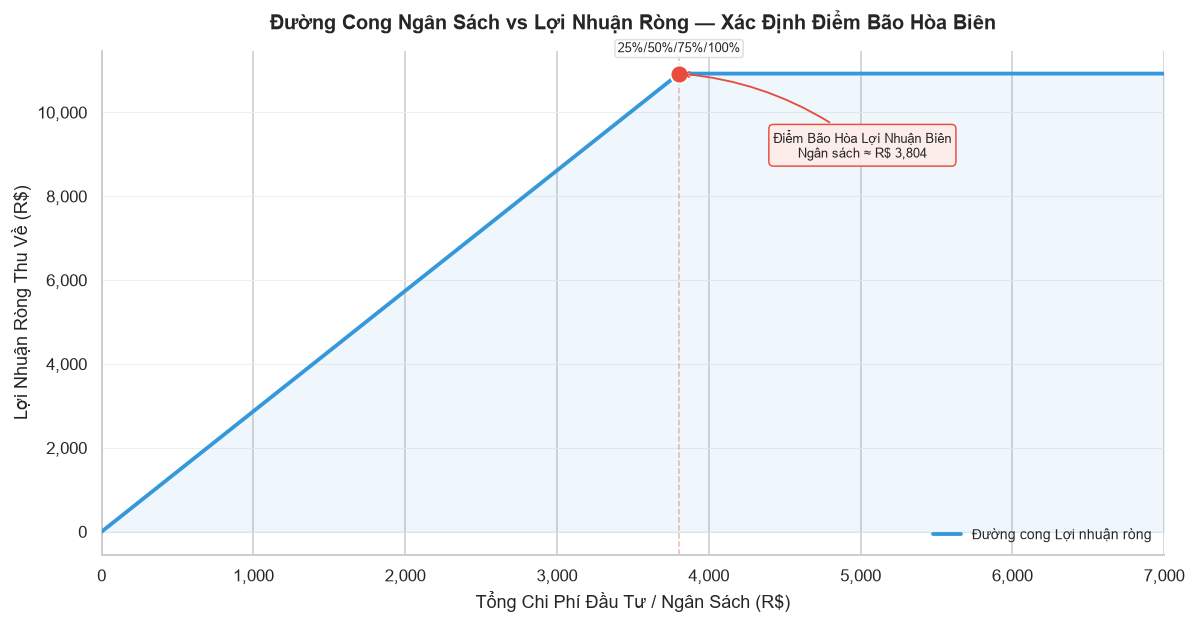

In [ ]:

fig, ax = plt.subplots(figsize=(11, 5.8))

# Bổ sung đoạn NGANG (plateau) sau điểm bão hòa — vì các mức ngân sách vượt
# điểm bão hòa đều cho cùng 1 kết quả tối ưu (đã bị dedup ở bước tính frontier_df ở trên),
# nên cần nối thêm để đường cong "chạy" hết được tới giới hạn trục X mong muốn (7.000)
peak_budget_tmp = frontier_df.loc[frontier_df["net_profit"].idxmax(), "budget"]
peak_profit_tmp = frontier_df["net_profit"].max()

plateau_extension = pd.DataFrame({
    "budget": np.linspace(peak_budget_tmp, 7000, 15),
    "net_profit": peak_profit_tmp,
})
frontier_df = pd.concat([frontier_df, plateau_extension], ignore_index=True) \
                 .drop_duplicates(subset="budget").sort_values("budget")


ax.plot(frontier_df["budget"], frontier_df["net_profit"],
        color=PALETTE["base"], linewidth=2.5, zorder=3,
        label="Đường cong Lợi nhuận ròng")
ax.fill_between(frontier_df["budget"], frontier_df["net_profit"],
                 color=PALETTE["base"], alpha=0.08, zorder=1)

# Đánh dấu điểm bão hòa biên (lợi nhuận ròng đạt cực đại) — dùng ô chú thích
# riêng, tách khỏi legend để không chồng lên các mốc ngân sách khác
idx_peak = frontier_df["net_profit"].idxmax()
peak_budget = frontier_df.loc[idx_peak, "budget"]
peak_profit = frontier_df.loc[idx_peak, "net_profit"]

ax.scatter([peak_budget], [peak_profit], color=PALETTE["logistics"], s=140,
           zorder=6, edgecolor="white", linewidth=1.3)
peak_is_right = peak_budget > frontier_df["budget"].median()
ax.annotate(
    f"Điểm Bão Hòa Lợi Nhuận Biên\nNgân sách ≈ R$ {peak_budget:,.0f}",
    xy=(peak_budget, peak_profit),
    xytext=(-120, -55) if peak_is_right else (120, -55),
    textcoords="offset points", fontsize=8.5, ha="center", zorder=7,
    arrowprops=dict(arrowstyle="->", color=PALETTE["logistics"], lw=1.2,
                     connectionstyle="arc3,rad=0.15"),
    bbox=dict(boxstyle="round,pad=0.35", fc="#fdecea", ec=PALETTE["logistics"], alpha=0.95),
)

# 4 mốc ngân sách điều hành (25/50/75/100%) — nếu nhiều mốc trùng đúng 1 điểm
# (ngân sách bão hòa sớm — hiện tượng thực tế khi rất ít KH có lợi nhuận dương),
# GỘP nhãn lại thành 1 điểm duy nhất thay vì chồng nhiều box lên nhau.
budget_marks = ["25% B_max", "50% B_max", "75% B_max", "100% B_max"]
mark_points = {}
for label in budget_marks:
    row = optimization_df[optimization_df["Mốc Ngân Sách"] == label].iloc[0]
    key = (round(row["Ngân Sách Đề Xuất (R$)"], 1), round(row["Lợi Nhuận Ròng (R$)"], 1))
    mark_points.setdefault(key, []).append(label.replace(" B_max", ""))

label_offset_cycle = [(0, 14), (0, -22), (55, 14), (-55, -22)]
for i, ((bx, by), labels) in enumerate(sorted(mark_points.items())):
    combined_label = "/".join(labels)
    dx, dy = label_offset_cycle[i % len(label_offset_cycle)]
    ax.scatter(bx, by, color=PALETTE["financial"], s=55, zorder=5,
               edgecolor="white", linewidth=1)
    ax.annotate(combined_label, (bx, by),
                textcoords="offset points", xytext=(dx, dy), fontsize=8.5,
                ha="center", zorder=6,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#dddddd", alpha=0.9))

ax.set_xlabel("Tổng Chi Phí Đầu Tư / Ngân Sách (R$)")
ax.set_ylabel("Lợi Nhuận Ròng Thu Về (R$)")
ax.set_title("Đường Cong Ngân Sách vs Lợi Nhuận Ròng — Xác Định Điểm Bão Hòa Biên", pad=14)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:,.0f}"))
ax.legend(fontsize=9, loc="lower right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#eeeeee", linewidth=0.7, zorder=0)
ax.axvline(peak_budget, color=PALETTE["logistics"], linestyle="--",
           linewidth=1, alpha=0.4, zorder=2)
ax.set_xlim(0, 7000)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_OUT_DIR, "executive_profit_frontier.png"),
            dpi=150, bbox_inches="tight")
plt.show()


**Nhận xét:**

- Độ dốc của đường cong thể hiện lợi nhuận biên trên mỗi R$ ngân sách bỏ thêm — đường càng phẳng dần về cuối nghĩa là các khách hàng được thêm vào sau có ROI thấp hơn.
- Điểm Bão Hòa Lợi Nhuận Biên là mức ngân sách tối thiểu cần thiết để "vét" hết toàn bộ khách hàng có lợi nhuận dương (ΔCLV > c_i); chi thêm ngân sách vượt điểm này không làm tăng lợi nhuận ròng.
- Nếu các mốc 25/50/75/100% B_max trùng vào cùng một điểm trên đường cong, đó là dấu hiệu ngân sách bão hòa rất sớm — tức là số khách hàng thực sự đáng "cứu" trong tệp Tier 2 nhỏ hơn nhiều so với quy mô ngân sách tối đa lý thuyết B_max, và phần ngân sách dư ra nên được cân nhắc chuyển sang mục tiêu khác (ví dụ mở rộng sang Tier 3) thay vì chi hết cho Tier 2.

### Biểu đồ 4/5 — So Sánh 3 Kịch Bản Điều Hành (`executive_scenario_comparison.png`)

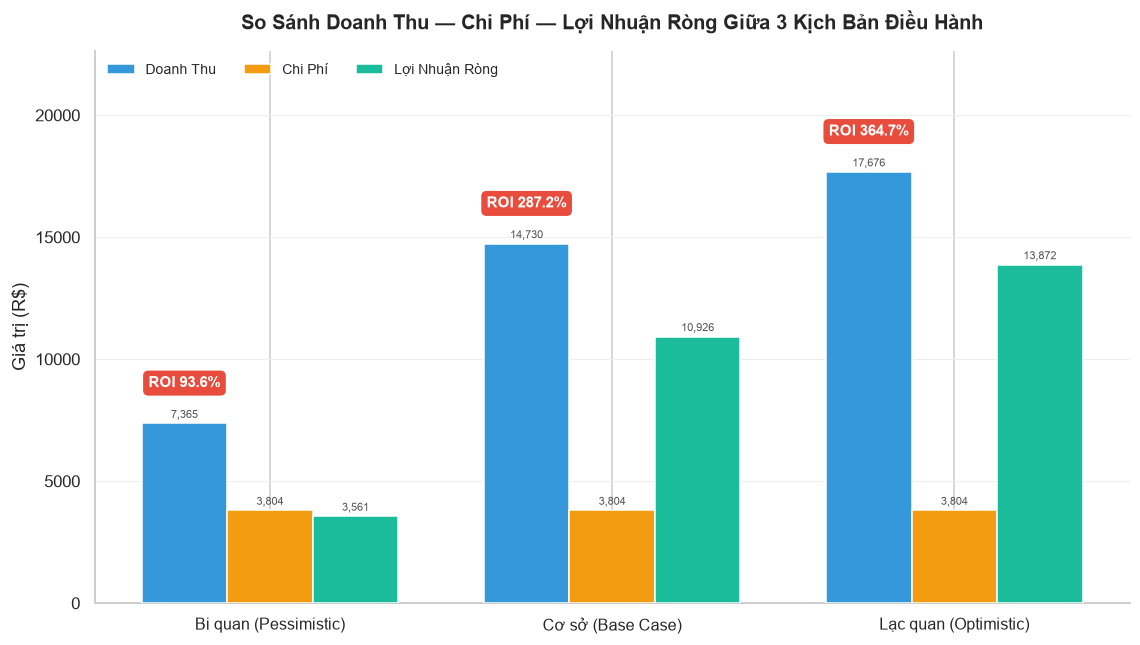

In [17]:

fig, ax = plt.subplots(figsize=(10.5, 6))

x = np.arange(len(scenario_df))
width = 0.25
metrics = ["Doanh Thu Tăng Thêm (R$)", "Chi Phí Đầu Tư (R$)", "Lợi Nhuận Ròng (R$)"]
short_labels = ["Doanh Thu", "Chi Phí", "Lợi Nhuận Ròng"]
colors_c4 = [PALETTE["base"], PALETTE["financial"], PALETTE["accent"]]

for i, (metric, short, color) in enumerate(zip(metrics, short_labels, colors_c4)):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, scenario_df[metric], width, label=short, color=color, zorder=3)
    # Nhãn giá trị NGANG (không xoay) đặt ngay trên đầu cột — dễ đọc hơn nhãn xoay 90°
    ax.bar_label(bars, labels=[f"{v:,.0f}" for v in scenario_df[metric]],
                 fontsize=7.5, padding=2, color="#555555")

ax.set_xticks(x)
ax.set_xticklabels(scenario_df["Kịch Bản"], fontsize=10.5)
ax.set_ylabel("Giá trị (R$)")
ax.set_title("So Sánh Doanh Thu — Chi Phí — Lợi Nhuận Ròng Giữa 3 Kịch Bản Điều Hành", pad=14)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#eeeeee", linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

# Mở rộng biên trên để có chỗ cho nhãn ROI (dạng huy hiệu) phía trên mỗi nhóm
ax.set_ylim(0, ax.get_ylim()[1] * 1.22)
ax.legend(fontsize=9, loc="upper left", frameon=False, ncol=3)

# ROI — điểm nhấn chính của biểu đồ: huy hiệu màu nổi bật phía trên cột Doanh Thu
revenue_bar_x_offset = -width
for i, (roi, revenue) in enumerate(zip(scenario_df["ROI (%)"], scenario_df["Doanh Thu Tăng Thêm (R$)"])):
    ax.text(i + revenue_bar_x_offset, revenue + ax.get_ylim()[1] * 0.06, f"ROI {roi:.1f}%",
            ha="center", va="bottom", fontsize=10, weight="bold", color="white", zorder=5,
            bbox=dict(boxstyle="round,pad=0.35", fc=PALETTE["logistics"], ec="none"))

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_OUT_DIR, "executive_scenario_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()


**Nhận xét:**

- Chênh lệch Lợi Nhuận Ròng giữa kịch bản Bi quan và Cơ sở cho biết mức độ nhạy cảm của kế hoạch với rủi ro thực thi (hiệu quả truyền thông, tốc độ CSKH phản hồi...).
- Nếu ROI ở kịch bản Bi quan vẫn dương, kế hoạch có biên an toàn tốt và có thể triển khai ngay cả khi hiệu quả thực tế thấp hơn dự báo AI.
- Chi Phí Đầu Tư giữ nguyên ở cả 3 kịch bản vì đây là biến số cố định (đã chốt ở phương án 100% B_max) — chỉ có Doanh Thu Tăng Thêm biến động theo hệ số hiệu quả giả định, nên ROI là chỉ số nên dùng để so sánh giữa 3 kịch bản thay vì lợi nhuận tuyệt đối.

### Biểu đồ 5/5 — Ma Trận Ngưỡng Hòa Vốn (`executive_break_even_heatmap.png`)

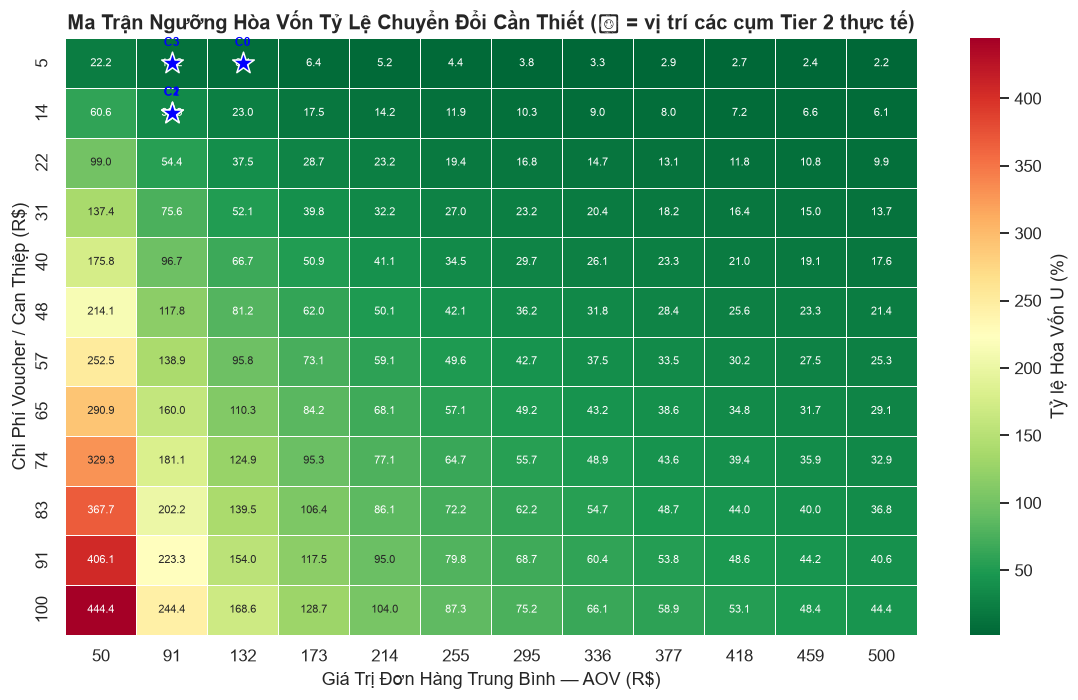

In [19]:

# Lưới AOV x Chi phí Voucher -> tỷ lệ chuyển đổi hòa vốn U_break-even
aov_grid = np.linspace(50, 500, 12)          # trục Giá trị Đơn hàng (R$)
cost_grid = np.linspace(5, 100, 12)          # trục Chi phí Voucher/Can thiệp (R$)

heatmap_matrix = np.zeros((len(cost_grid), len(aov_grid)))
for i, c in enumerate(cost_grid):
    for j, aov in enumerate(aov_grid):
        heatmap_matrix[i, j] = c / (aov * NET_MARGIN_M * REPEAT_FACTOR_F) * 100  # %

fig, ax = plt.subplots(figsize=(10.5, 6.5))

sns.heatmap(
    heatmap_matrix, ax=ax, cmap="RdYlGn_r", cbar_kws={"label": "Tỷ lệ Hòa Vốn U (%)"},
    xticklabels=[f"{v:.0f}" for v in aov_grid],
    yticklabels=[f"{v:.0f}" for v in cost_grid],
    annot=True, fmt=".1f", annot_kws={"fontsize": 7},
    linewidths=0.4, linecolor="white",
)

# Đánh dấu vị trí 4 cụm thực tế của tệp Tier 2 lên heatmap
for _, row in cluster_profile.iterrows():
    j = np.argmin(np.abs(aov_grid - row["AOV_k"]))
    i = np.argmin(np.abs(cost_grid - row["c_k"]))
    ax.scatter(j + 0.5, i + 0.5, marker="*", s=220, color="blue",
               edgecolor="white", linewidth=1, zorder=5)
    ax.text(j + 0.5, i + 0.15, f"C{int(row['cluster_id'])}", color="blue",
            fontsize=8, weight="bold", ha="center")

ax.set_xlabel("Giá Trị Đơn Hàng Trung Bình — AOV (R$)")
ax.set_ylabel("Chi Phí Voucher / Can Thiệp (R$)")
ax.set_title("Ma Trận Ngưỡng Hòa Vốn Tỷ Lệ Chuyển Đổi Cần Thiết (★ = vị trí các cụm Tier 2 thực tế)")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_OUT_DIR, "executive_break_even_heatmap.png"),
            dpi=150, bbox_inches="tight")
plt.show()


**Nhận xét:**

- Vùng màu xanh đậm (U thấp) là vùng "dễ hòa vốn" — chi phí can thiệp thấp so với AOV, tỷ lệ khách hàng cần cứu vãn thành công để hòa vốn chỉ cần rất nhỏ.
- Cụm nào rơi vào vùng màu đỏ/cam (U cao, thường ở góc AOV thấp – chi phí cao) là cụm rủi ro nhất về mặt tài chính — cần tỷ lệ chuyển đổi thực tế rất cao mới hòa vốn, nên cân nhắc giảm chi phí gói can thiệp ($c_k$) hoặc loại khỏi danh sách ưu tiên ngân sách.
- Đường đồng mức (contour) cho biết ngưỡng hòa vốn lý thuyết U tại từng vùng — so sánh U của mỗi cụm với ΔP_i thực tế mô phỏng được ở Bước 4: nếu ΔP_i trung bình của cụm thấp hơn nhiều so với U tại vị trí đó trên bản đồ, gói can thiệp cho cụm này đang lỗ về mặt kỳ vọng.

---
## Bước 8: Xuất Dữ Liệu Bàn Giao (Deliverables & Verification)

Xuất `prescriptive_action_plan.csv` chứa đầy đủ:
danh sách khách hàng Tier 2, phân cụm gán, chi phí can thiệp động $c_i$,
xác suất gốc $P_0$, xác suất phản thực tế $P_{\text{new}}$ và quyết định cấp ngân sách $x_i$
(theo phương án ngân sách 100% $B_{\max}$).


In [20]:

action_plan = tier2_df[[
    "customer_unique_id", "cluster_id", "assigned_friction", "assigned_package",
    "c_i", "P_original", "P_counterfactual", "delta_P", "delta_CLV",
]].copy()

action_plan = action_plan.rename(columns={
    "P_original": "P0_original_probability",
    "P_counterfactual": "P_new_counterfactual_probability",
    "c_i": "intervention_cost",
})

action_plan["x_i_selected_100pct_budget"] = x_selected.astype(int)
action_plan["x_i_selected_unconstrained"] = tier2_df["x_unconstrained"].values

action_plan.to_csv(PATH_ACTION_PLAN_CSV, index=False, encoding="utf-8-sig")

print(f"Đã xuất kế hoạch hành động cho {len(action_plan):,} khách hàng Tier 2 -> {PATH_ACTION_PLAN_CSV}")
action_plan.head(10)


Đã xuất kế hoạch hành động cho 13,525 khách hàng Tier 2 -> .\data\prescriptive_action_plan.csv


,customer_unique_id,cluster_id,assigned_friction,assigned_package,intervention_cost,P0_original_probability,P_new_counterfactual_probability,delta_P,delta_CLV,x_i_selected_100pct_budget,x_i_selected_unconstrained
0,0000366f3b9a7992bf8c76cfdf3221e2,0,financial,Financial Relief (Gói Kích Cầu Thanh Khoản),8.456634,0.299635,0.255938,0.000000,0.000000,0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,3,category,Category Re-engagement (Gói Tái Tương Tác Ngành),6.230208,0.179082,0.179082,0.000000,0.000000,0,0
2,000ed48ceeb6f4bf8ad021a10a3c7b43,3,category,Category Re-engagement (Gói Tái Tương Tác Ngành),6.230208,0.228237,0.254543,0.026306,0.152468,0,0
3,000fbf0473c10fc1ab6f8d2d286ce20c,3,category,Category Re-engagement (Gói Tái Tương Tác Ngành),6.230208,0.095944,0.164745,0.068800,8.848381,1,1
4,00196c4c9a3af7dd2ad10eade69c926f,3,category,Category Re-engagement (Gói Tái Tương Tác Ngành),6.230208,0.161934,0.160309,0.000000,0.000000,0,0
5,0019e8c501c85848ac0966d45226fa1d,3,category,Category Re-engagement (Gói Tái Tương Tác Ngành),6.230208,0.156768,0.648664,0.491896,35.414284,1,1
6,001a34eb30ecb8e3aacb07c475ca4dd1,3,category,Category Re-engagement (Gói Tái Tương Tác Ngành),6.230208,0.159020,0.173068,0.014049,0.960298,0,0
7,001deb796b28a3a128d6113857569aa4,0,financial,Financial Relief (Gói Kích Cầu Thanh Khoản),8.456634,0.108810,0.095751,0.000000,0.000000,0,0
8,002311514717ca8b65b09a26cdf7b91a,3,category,Category Re-engagement (Gói Tái Tương Tác Ngành),6.230208,0.183481,0.183873,0.000391,0.020467,0,0
9,00256bf7b05c08f6a5849df3d0a64f1f,1,review,Service Resolution (Gói Chăm Sóc & Đổi Trả),12.011951,0.223816,0.221071,0.000000,0.000000,0,0


---
## Tổng Kết Điều Hành (Executive Summary)

* **Tệp Tier 2 (Savable Customers):** phân rã thành `K_OPTIMAL` cụm chân dung điểm nghẽn cụ thể.
* **4 gói can thiệp** được gán chi phí động theo đúng chỉ số tài chính thực tế từng cụm — không
  dùng tỷ lệ giả định.
* **Mô phỏng phản thực tế XGBoost** cho phép định lượng $\Delta P_i$ và $\Delta \text{CLV}_i$ ở
  mức cá nhân hóa từng khách hàng, thay vì gán một tỷ lệ cứu vãn cảm tính.
* **Tối ưu hóa ILP (knapsack 0/1)** xác định phương án phân bổ ngân sách tối đa hóa lợi nhuận
  ròng tại 5 mốc điều hành (25/50/75/100% $B_{\max}$ và Ngân Sách Tự Do Tối Ưu).
* **3 kịch bản Bi quan / Cơ sở / Lạc quan** cung cấp dải kết quả tài chính để Ban Giám Đốc đánh
  giá rủi ro trước khi phê duyệt ngân sách.
* Toàn bộ 5 biểu đồ điều hành đã được xuất ra `fix/04_Prescriptive/figures/` và dữ liệu hành
  động chi tiết đã được xuất ra `fix/04_Prescriptive/data/prescriptive_action_plan.csv`, sẵn
  sàng phục vụ báo cáo `prescriptive_analysis_report.md`.
